In [ ]:
# ========================================================
# ST2195 Coursework PART 1 
# Name: Stacia Tan Rui Shi
# Student ID: 240509602
# ========================================================

In [4]:
#PART 1A
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [5]:
def log_f(x):
    "Calculates the log of the target density f(x)."
    return np.log(0.5) - np.abs(x)

Monte Carlo Estimate of Meam:  0.0723
Monte Carlo Estimate of Standard Deviation: 1.4269


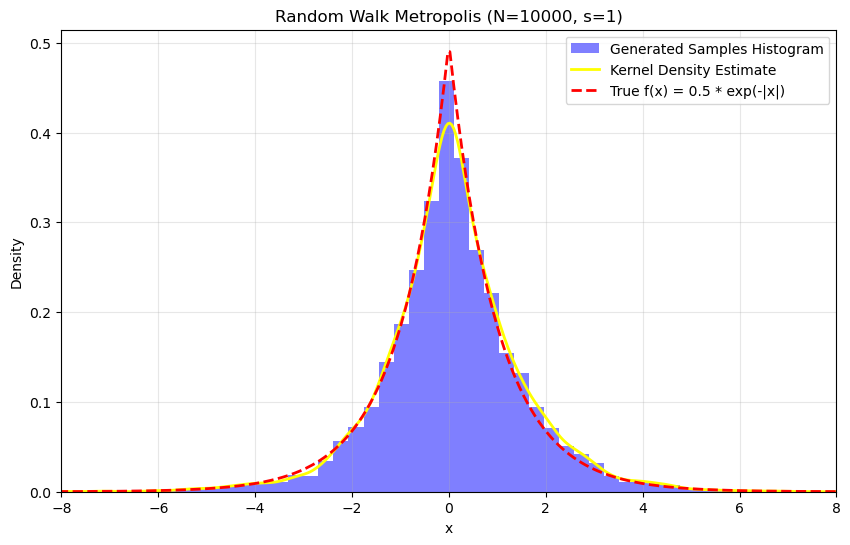

In [14]:
def metropolis_hastings(N, s, x0): #N = N times, s = scale, x0 = starting point
    "Random walk Metropolis algorithm."
    samples = np.zeros(N + 1)
    samples[0] = x0

    for i in range(1, N +1): #repeat the next indented step N times 
        x_prev = samples[i -1] #look at the previous number 
        x_star = np.random.normal(loc=x_prev, scale=s) #suggest a new number by pulling a random num from a normal dist.
        #loc = x_prev : centers guess around previous num, s = how far away to look
        log_ratio = log_f(x_star) - log_f(x_prev)
        u = np.random.uniform(0, 1) #generating a random uniform number between 0 and 1
        if np.log(u) < log_ratio:
            samples[i] = x_star #Accept 
        else:
            samples[i] = x_prev #Reject
    return samples

set up prarameters and run simulation 
N = 10000
s = 1 
x0 = 0.0

samples = metropolis_hastings(N, s, x0)
#Discard intial value x0 for the final sample set
final_sample = samples[1:]

compute sample mean and standard deviation
sample_mean = np.mean(final_sample)
sample_std = np.std(final_sample, ddof=1)

print(f"Sample Mean: {sample_mean: .4f}")
print(f"Sample Standard Deviation: {sample_std:.4f}")

#Defining a range for the true density function 
x_range = np.linspace(-10, 10, 500)
#True density function f(x) 
true_f = 0.5 * np.exp(-np.abs(x_range))

#Calculating KDE 
kde = gaussian_kde(final_sample)
kde_y = kde(x_range)

plt.figure(figsize=(10, 6))
plt.hist(final_sample, bins=50, density=True, alpha=0.5, color='blue', label='Generated Samples Histogram')
plt.plot(x_range, kde_y, color='yellow', linewidth=2, label='Kernel Density Estimate')
plt.plot(x_range, true_f, color='red', linestyle='--', linewidth=2, label='True f(x) = 0.5 * exp(-|x|)')
plt.title(f'Random Walk Metropolis (N={N}, s={s})')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-8, 8)
plt.show()

R_est for N=2000, s=0.001, J=4: 106.4023


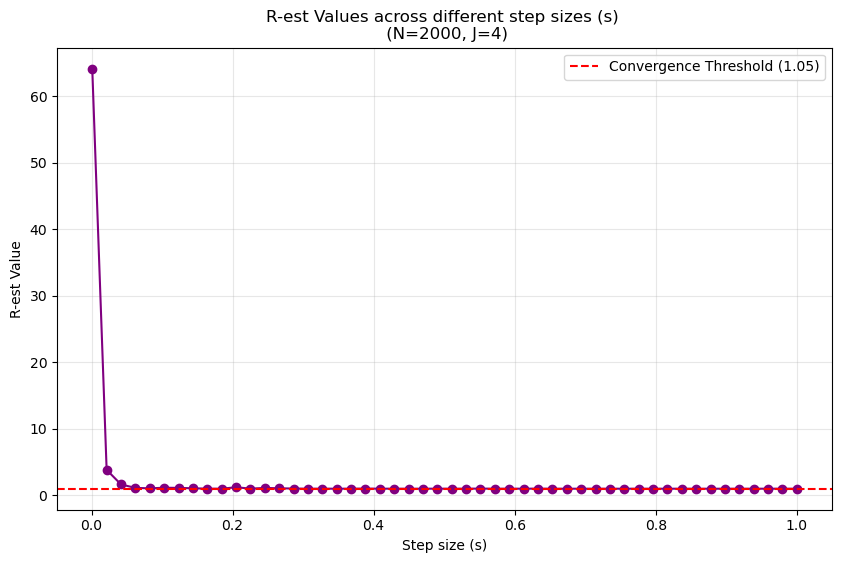

In [17]:
## part a assumes that algo works- what if it doesnt? part b is basically 
## sending many different checkers at diff starting points and diff chains to check if it worked
#PART 1B
import numpy as np
import matplotlib.pyplot as plt
def calculate_R_est(N, s, J, inital_values):
    "Calculate the R-estimate convergence diagnostic for J chains."
    chains = [] #generating chains for J sequences 
    for j in range(J):
        chain = metropolis_hastings(N, s, initial_values[j])
        chains.append(chain[1:])
    chains = np.array(chains) #convert list of chain to array 
    M_J = np.mean(chains, axis=1) #sample mean
    V_J = np.var(chains, axis=1, ddof = 0) #sample variance 
    W = np.mean(V_J) #mean of sample variance V 
    M = np.mean(M_J) #overall sample mean
    B = np.var(M_J, ddof=0)
    R_est = np.sqrt((B + W) / W) 
    return R_est

#requirements in brief
N = 2000
s = 0.001
J = 4
s_test = 0.001 
initial_values = [-2.0, -1.0, 1.0, 2.0] 

R_est_value = calculate_R_est(N, s_test, J, initial_values)
print(f"R_est for N={N}, s={s_test}, J={J}: {R_est_value:.4f}")

s_grid = np.linspace(0.001, 1.0,50) 
R_est_results = []

for s_val in s_grid:     #looping every s value in our grid
    R_est = calculate_R_est(N, s_val, J, initial_values) #calc r estimate
    R_est_results.append(R_est)

plt.figure(figsize=(10, 6))
plt.plot(s_grid, R_est_results, marker='o', linestyle='-', color='purple')
plt.axhline(y=1.0, color='red', linestyle='--', label='Convergence Threshold (1.05)')
#values of R est close to 1 indicate convergence = good
plt.title(f'R-est Values across different step sizes (s) \n (N={N}, J={J})')
plt.xlabel('Step size (s)')
plt.ylabel('R-est Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()